In [38]:
#Import Libraries
import numpy as np
import cv2 as cv2
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
#Routine to fix 
def fixColor(image):
    return(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

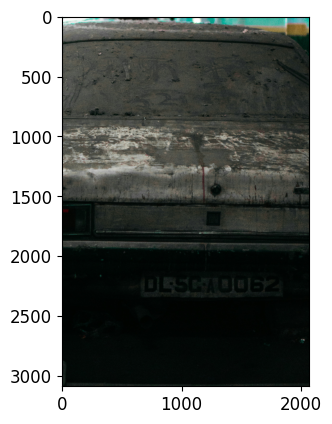

In [39]:
#Input the Image
image = cv2.imread('/kaggle/input/cropped-license-plate/Croppedprateek-katyal-NHE252Af6kA-unsplash.jpg')
plt.imshow(fixColor(image))

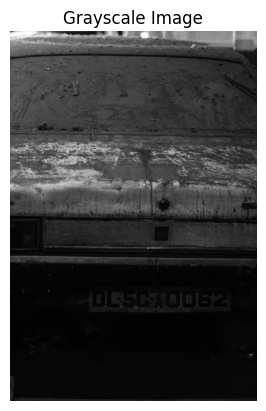

In [40]:
#PreProcessing the Image
#Grayscale image 
# Convert the image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display the grayscale image
plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.show()


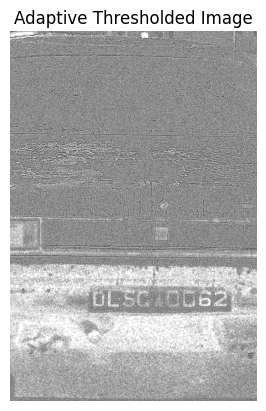

In [41]:
th2 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                            cv2.THRESH_BINARY, 11, 2)
# Display the result
plt.imshow(th2, cmap='gray')
plt.title('Adaptive Thresholded Image')
plt.axis('off')
plt.show()


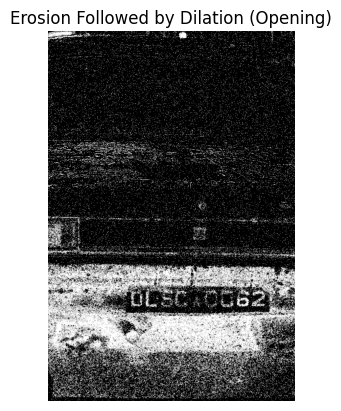

In [42]:
# Define a kernel
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

# Apply erosion to remove noise
eroded = cv2.erode(th2, kernel, iterations=1)

# Apply dilation to enhance the text
dilated = cv2.dilate(eroded, kernel, iterations=1)

# Display the result
plt.imshow(dilated, cmap='gray')
plt.title('Erosion Followed by Dilation (Opening)')
plt.axis('off')
plt.show()


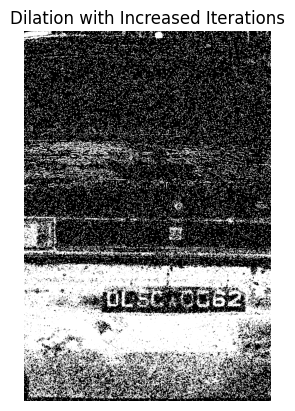

In [43]:
# Apply dilation with increased iterations to enhance the text
dilated = cv2.dilate(eroded, kernel, iterations=2)

# Display the result
plt.imshow(dilated, cmap='gray')
plt.title('Dilation with Increased Iterations')
plt.axis('off')
plt.show()


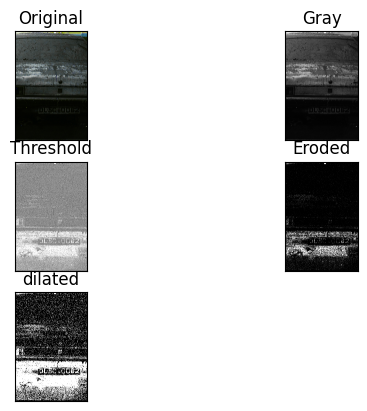

In [44]:
images = [image, gray, th2, eroded, dilated]
titles = ['Original', 'Gray', 'Threshold', 'Eroded', 'dilated']
for i in range(5):
    plt.subplot(3,2,i+1),plt.imshow(images[i],'gray')
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()
